In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from mkid import MKID, ReadoutParams, NoiseParams, PulseParams
from scipy.signal import welch, csd as scipy_csd

In [3]:
# Some usefull PSD and plotting functions (for later) 
def PSD(x, fs=200e3, nperseg=4096):
    """Power spectral density."""
    freqs, psd = welch(x, fs=fs, nperseg=nperseg, window='hann')
    return freqs, psd

def plot_PSD_grid(panels, fs=200e3, nperseg=4096, n_decades=4,
                  figsize=(14, 7), suptitle=None):
    """
    Plot a grid of PSD panels.
    
    Args:
        panels: list of lists defining the grid. Each entry is a dict:
            {
                'traces': [(array, label, color), ...],
                'title': str,
                'ylabel': str,
                'ylim': (lo, hi) or None,   # optional manual override
                'xlim': (lo, hi) or None,   # optional manual override
            }
            Organized as panels[row][col].
        fs: sample rate (Hz)
        nperseg: PSD segment length
        n_decades: auto y-range decades below max (used if ylim not set)
        figsize: figure size
        suptitle: figure title
        
    Returns:
        fig, axes
        
    Example:
        panels = [
            [  # Row 0
                {'traces': [(dI_det, 'Det I', 'steelblue'),
                            (dI_clean, 'Clean I', 'darkorange')],
                 'title': 'Electronics: I', 'ylabel': 'PSD (ADCu²/Hz)'},
                {'traces': [(dS21_det.real, 'Det', 'steelblue')],
                 'title': 'Re(δS₂₁)', 'ylabel': 'PSD (δS₂₁²/Hz)'},
            ],
            [  # Row 1
                ...
            ],
        ]
        fig, axes = plot_PSD_grid(panels)
    """
    nrows = len(panels)
    ncols = max(len(row) for row in panels)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    # Ensure axes is always a 2D array
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    
    for i, row in enumerate(panels):
        for j, panel in enumerate(row):
            ax = axes[i, j]
            
            for trace in panel['traces']:
                data, label, color = trace
                freqs, psd = PSD(data, fs=fs, nperseg=nperseg)
                ax.loglog(freqs, psd, color=color, lw=0.8, label=label)
            
            ax.set_title(panel.get('title', ''), fontsize=10)
            ax.set_ylabel(panel.get('ylabel', ''), fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3, which='both')
            
            if i == nrows - 1:
                ax.set_xlabel('Frequency (Hz)')
            
            # Y-limits: manual or auto
            if panel.get('ylim'):
                ax.set_ylim(panel['ylim'])
            else:
                ymax = ax.get_ylim()[1]
                ax.set_ylim(bottom=ymax / 10**n_decades, top=ymax * 2)
            
            # X-limits: manual or auto
            if panel.get('xlim'):
                ax.set_xlim(panel['xlim'])
    
    plt.tight_layout()
    plt.show()
    return fig, axes


In [4]:
# Initilize an MKID object, you should ignore all the parameters we pass here for now

m = MKID(
    noise_params = NoiseParams(
    tls_Sf0=1e5,         # TLS: 1/f frequency noise amplitude at 1 Hz
    tls_alpha=0.5,       # TLS: spectral slope (1/f^0.5)
    hemt_sigma=0.0003,    # HEMT: white noise floor in IQ
    lo_Sphi0=5e-3,       # LO: phase noise amplitude at 1 Hz (DOMINANT)
    lo_alpha=1.0,        # LO: spectral slope (1/f)
    lo_white=1e-8,       # LO: white floor (so it rolls off at high freq)
    )
    , 
    seed=42,
    pulse_params=PulseParams(
        tau_rise=  5.0e-4,       # Quasiparticle thermalization time (s)
        tau_fall=  1.0e-2,      # Quasiparticle recombination time (s)

        # Material parameters
        Tc= 1.2,                # Critical temperature (K)
        alpha_f= 0.05,          # Kinetic inductance fraction (freq shift)
        alpha_Q= 0.05,          # Kinetic inductance fraction (dissipation)
        volume= 1.2e-14,       # Absorber volume (m³)
        T_bath= 0.1,            # Bath temperature (K)
        C_override=8e-17,   # ← Artificial C for nice dynamic range
    ),
)


## Part 1: what's an MKID:
MKIDs are superconducting microwave resonators forming an LC circuit. When an above-gap energy quanta (photon, phonon) is absorbed, it can break Cooper pairs into quasiparticles, changing the kinetic inductance and surface resistance of the film. This shifts the resonance frequency $f_r$ and changes the internal quality factor $Q_i$. To read out the detector, we monitor the complex transmission $S_{21}$ of a microwave tone placed near resonance. MKIDS can be useful as both photon detectors, and as environmental sensors for quantum circuits.  

One of the first characterizations we do when we cool down an MKID is to measure S21 resonse as we sweep the frequency of a readout tone. 

In [5]:
f_sweep, S21_sweep =  m.frequency_sweep(4.995e9, 5.0025e9, n_points=500, ifbw=10000, readout_power_dBm=-115)

Displaying the results:

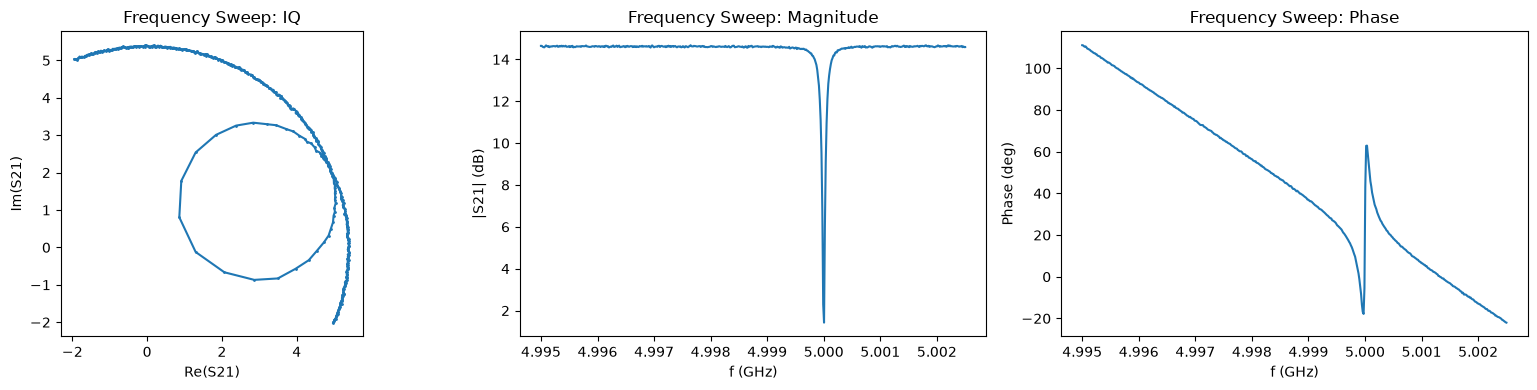

In [6]:
# now plot the results of the frequency sweep:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(S21_sweep.real, S21_sweep.imag, '.-', markersize=2)
axes[0].set_xlabel('Re(S21)')
axes[0].set_ylabel('Im(S21)')
axes[0].set_title('Frequency Sweep: IQ')
axes[0].set_aspect('equal')

axes[1].plot(f_sweep/1e9 , 20 * np.log10(np.abs(S21_sweep)))
axes[1].set_xlabel('f (GHz)')
axes[1].set_ylabel('|S21| (dB)')
axes[1].set_title('Frequency Sweep: Magnitude')

axes[2].plot(f_sweep/1e9 , np.angle(S21_sweep, deg=True))
axes[2].set_xlabel('f (GHz)')
axes[2].set_ylabel('Phase (deg)')
axes[2].set_title('Frequency Sweep: Phase')

plt.tight_layout()
plt.show()

We can describe our detector's frequency-dependent S21 response through the device, amplifiers, and cables measured as:

$S_{21}(f)=a e^{-2\pi i \tau (f-f_r)}\left(1-\frac{Q_r}{\hat{Q}_c}\frac{1}{1 + 2iQ_r\frac{f-f_r}{f_r}}\right)$

Here the quantity inside the parentheses corresponds to the ideal resonator response, with $f_r$ indicating the resonance frequency. The ratio of the energy stored and the loss of energy from the resonator per cycle can be broken into dissipative and non-dissipative components, described by $Q_i$ and $Q_c$ respectively. The resonator quality factor is then given as: $\frac{1}{Q_r} = \frac{1}{Q_i} + \frac{1}{Q_c}$.

We reparametrize $Q_c$ as a complex number $\hat{Q}_c = |Q_c| e^{-i\phi}$ to include impedance mismatches along the feedline.

Outside the parentheses, $\tau$ describes the phase delay due to readout cables, and $a$ is a complex number describing the gain and phase shift of the system.


<span style="color:red"> Please fit the frequency-dependent S21 response to the above equation, to extract: </span>
$\color{red}{a, \tau, f_r, Q_r, \hat{Q}_c}$

 Hints for seeding the fit:
- $f_r$: Where is the minimum of $|S_{21}|$? 
- $Q_r$: another useful definition of $Qr$ is $Q_r=\frac{f_r}{FWHM}$.
- $\tau$: consider what the analytical $S_{21}$ response is far off resonance.
- $a$: The mean value of $|S_{21}|$ far from resonance. 
- Fit the complex $S_{21}$ (real and imaginary simultaneously), not just the magnitude!

In [ ]:
###  Pseudo code for fitting: 

# Define S21(f, params) function
def S21(f, fr, Qr, Qc, tau, a):
    Delta = f - fr
    S21 = a*np.exp(-2*np.pi*1j*tau*Delta)*(1-(Qr/Qc)*(1+2*1j*Qr*Delta/fr)**(-1))
    return S21

# Make guesses for each parameter from the data
a_guess = 1
fr_guess = 1
Qr_guess = 1
Qc_guess = 1
tau_guess = 1
a_guess = 1

# fit the real and imaginary components of S21 simultaneously to extract the best-fit parameters.

# end with a dictionary of fit parameters: 
#   fit_params = {
#       'fr': ____,
#       'Qr': ____,
#       'QcHatmag': ____,
#       'phi_c': ____,
#       'tau': ____,  
#       'a': ____,}

<span style="color:blue"> Q1: How does the ratio of Qi to Qc affect the ideal resonator response? Consider three regimes: $Q_i > Q_c$, $Q_i = Q_c$, and $Q_i < Q_c$. What sets the depth of the resonance dip? Which regime is best for readout and why? </span>


<span style="color:blue"> Q2: What is the fastest timescale on which the resonator can respond to a change in fr? Express your answer in terms of the resonator parameters. For fr = 5 GHz and Qr = 50,000, what is this timescale? </span>

## Part 2: Look at events in MKIDs
Now that we know our resonant frequency, We can "stream" the MKID's time-dependent S21 transmission at fixed readout frequencies.

 To start, we will set 3 tones: one on-resonance, and two far off resonance to monitor the other RF electronics in the readout chain. We will call these off-resonance tones our "cleaning" tones. 

In [ ]:
# set up your timestreaming measurement:
cl_offset_0 = 2.0e6
cl_offset_1 = 2.5e6

m.readout = ReadoutParams(
    f_tone=fit_params['fr'],           # Place tone on resonance
    f_clean=[              # Two off-resonance cleaning tones
        fit_params['fr'] - cl_offset_0,    # 2 MHz below resonance
        fit_params['fr'] + cl_offset_1,    # 2.5 MHz above resonance
    ],
    fs=500e3,              # 500 kHz sample rate
)

In [ ]:
# start by takeing your timestream with (essentially) no events
data = m.timestream(
    duration=1,                    # 1 second
    photon_rate=2,               # 50 photons/sec
    energy_distribution='uniform',  # uniform energy distribution
    fixed_energy=.01,                # Fixed photon energy (eV) #60
)
data.fs = 1/ (data.t[1] - data.t[0])  # sample rate (Hz)

We can plot what this timestream data will look like in complex space, as well as the PSD of the timestreams. 

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 5))
axs = [axs]
#axs[0]: complex plane plot
axs[0].plot(S21_sweep.real, S21_sweep.imag, 'k-', label='S21_sweep')
axs[0].plot(data.I_det,data.Q_det,'.-', label='det timestream')
for i in range(len(data.I_clean)):
    axs[0].plot(data.I_clean[i], data.Q_clean[i],'.', label=f'cleaning tone {i}')
axs[0].set_xlabel('I')
axs[0].set_ylabel('Q')
axs[0].set_title('Complex Plane Plot')
axs[0].set_aspect('equal')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('MKID Timestreams in IQ space: Raw Electronics Basis', fontsize=16)
plt.show()

## Readout Basis Transformations

So far we've been looking at our timestream in raw I(t) and Q(t) — the voltages that come out of our digitizer. But this is an arbitrary basis set by the electronics (LO phase, cable lengths, etc.). The *physics* of the resonator doesn't live in I/Q — it lives in frequency shifts and dissipation changes.

We can transform our IQ data into progressively more physical coordinate systems:

### 1. Electronics Basis (raw I, Q)
What the ADC gives you. The axes are set by the LO phase and amplitude — physically arbitrary.

### 2. Fractional Electronics Basis (δS₂₁)
Remove gain and offset to get a dimensionless perturbation:
$$\delta S_{21}(t) = \frac{S_{21}(t)}{a \, e^{-2\pi i \tau (f_{tone} - f_r)}} - S_{21}^{ideal}(f_r)$$

i.e., divide out cable delay and system gain, then subtract the quiescent on-resonance value. Now your data lives in the "ideal resonator" frame.

### 3. Resonator Basis (δf/f, δ(1/Qᵢ))
If the resonator is perturbed ($f_r \to f_r + \delta f_r$, $Q_i \to Q_i + \delta Q_i$), expanding $S_{21}^{ideal}$ to first order at the tone frequency gives:

$$\delta S_{21} = \frac{Q_r^2}{Q_c}\left(\delta\frac{1}{Q_i} - 2i\frac{\delta f_r}{f_r}\right)$$

Inverting:

$$\frac{\delta f_r}{f_r} = -\frac{Q_c}{2\,Q_r^2} \; \text{Im}(\delta S_{21}), \qquad \delta\frac{1}{Q_i} = \frac{Q_c}{Q_r^2} \; \text{Re}(\delta S_{21})$$

The real part of δS₂₁ maps to dissipation; the imaginary part maps to frequency shift. Both are amplified by $Q_r^2/Q_c$ — higher Q means more sensitive readout.

---
<span style="color:red">**Task:** Transform your detector and cleaning tone timestreams into all three bases. Plot the PSD of each quadrature. In which basis and quadrature is the photon signal most visible above the noise?</span>

In [ ]:
### Pseudo code for coordinate transformations:

# start by giving general functions for the transformations.
    # define to_dS21 function
    # # define to_resonator_basis function

# Now apply transformations to the three coordinate systems for the on resonance detector tone. 
# Each variable below is a 1D array of length N, where N is the number of samples in the timestream.

    # --- Detector tone ---
    # Basis 1: Electronics (raw)
    # dI_det = __________
    # dQ_det = __________

    # Basis 2: Fractional δS21
    # dS21_det = to_dS21(__________)

    # Basis 3: Resonator
    # df_f_det, d_inv_Qi_det = to_resonator_basis(__________)


# now repeat the same for the cleaning tone:

    # --- Cleaning tone ---
    # Basis 1: Electronics (raw)
    #dI_clean = __________
    #dQ_clean = __________

    # Basis 2: Fractional δS21
    # dS21_clean = to_dS21(__________)

    # Basis 3: Resonator (for cleaning tone, this is just scaled noise)
    # df_f_clean, d_inv_Qi_clean = to_resonator_basis(__________)


In [ ]:
# If you have the variables defined above, this should plot nicely:
panels = [
    [   # Row 0: dissipation-like quadrature
        {'traces': [(dI_det, 'Det I', 'steelblue'),
                    (dI_clean, 'Cleaning tone I', 'darkorange')],
         'title': 'Electronics: I', 'ylabel': 'PSD (ADCu²/Hz)',
         'ylim': (1e-16, 1e-1)},
        
        {'traces': [(dS21_det.real, 'Det Re(δS₂₁)', 'steelblue'),
                    (dS21_clean.real, 'Cleaning tone Re(δS₂₁)', 'darkorange')],
         'title': 'Re(δS₂₁) → dissipation', 'ylabel': 'PSD (δS₂₁²/Hz)',
         'ylim': (1e-16, 1e-1)},
        
        {'traces': [(d_inv_Qi_det, 'Det δ(1/Qᵢ)', 'steelblue'),
                    (d_inv_Qi_clean, 'Cleaning tone δ(1/Qᵢ)', 'darkorange')],
         'title': 'δ(1/Qᵢ) — dissipation', 'ylabel': 'PSD ((1/Q)²/Hz)',
         'ylim': (1e-30, 1e-1)},
    ],
    [   # Row 1: frequency-like quadrature
        {'traces': [(dQ_det, 'Det Q', 'steelblue'),
                    (dQ_clean, 'Cleaning tone Q', 'darkorange')],
         'title': 'Electronics: Q', 'ylabel': 'PSD (ADCu²/Hz)',
         'ylim': (1e-16, 1e-1)},

        {'traces': [(dS21_det.imag, 'Det Im(δS₂₁)', 'steelblue'),
                    (dS21_clean.imag, 'Cleaning tone Im(δS₂₁)', 'darkorange')],
         'title': 'Im(δS₂₁) → frequency', 'ylabel': 'PSD (δS₂₁²/Hz)',
         'ylim': (1e-16, 1e-1)},
        
        {'traces': [(df_f_det, 'Det δf/f', 'steelblue'),
                    (df_f_clean, 'Cleaning  δf/f', 'darkorange')],
         'title': 'δf/f — frequency', 'ylabel': 'PSD ((δf/f)²/Hz)',
         'ylim': (1e-30, 1e-1)},
    ],
]

fig, axes = plot_PSD_grid(panels, fs=data.fs, suptitle='Readout Basis Comparison')


<span style="color:blue">**Q3:** Compare the PSDs of the on-resonance and off-resonance (cleaning) tones in each basis. Which noise sources are common-mode (appear in both)? Which are unique to the detector tone?</span>


## Identifying Correlated Noise: Cross-Spectral Density & Coherence
Frequency multiplexing in MKIDs provides a natural way to remove correlated electronics noise: we simultaneously read out **off-resonance tones** that see the same system (amplifier chain, LO, cables) but *no detector signal*. Any noise that appears in both the on-resonance and off-resonance timestreams must be common-mode systematics — not photons.


Before we clean, we need to understand **how much** of the detector noise is correlated with the cleaning tone, and **at which frequencies**.

### Cross-Spectral Density (CSD)

The CSD between two signals $D(t)$ and $S(t)$ is the frequency-domain analog of the cross-correlation:

$$C_{DS}(f) = \langle \tilde{D}(f) \, \tilde{S}^*(f) \rangle$$

where $\tilde{D}(f)$ is the Fourier transform of $D(t)$. The CSD is complex — its magnitude tells you how much power is shared at each frequency, and its phase tells you the relative timing/phase between the two signals.

### Coherence

The **magnitude-squared coherence** normalizes the CSD by the individual PSDs:

$$\gamma^2(f) = \frac{|C_{DS}(f)|^2}{P_{DD}(f) \cdot P_{SS}(f)}$$

This gives a number between 0 and 1 at each frequency:
- $\gamma^2 = 1$: noise is **perfectly correlated** at that frequency (100% shared)  
- $\gamma^2 = 0$: noise is **completely independent** (nothing in common)
- $\gamma^2 = 0.5$: half the noise power is shared

**Interpretation:** The coherence tells you the maximum possible improvement from cleaning at each frequency. If $\gamma^2 = 0.8$ at 10 Hz, then 80% of the detector noise at 10 Hz comes from a source shared with the cleaning tone (LO noise), and cleaning can in principle remove it. The remaining 20% is intrinsic (TLS, signal) and cannot be cleaned.

<span style="color:blue">**Q5:** At what frequencies is the coherence high? What physical noise source is responsible? Why does the coherence drop at high frequencies?</span>

<span style="color:blue">**Q6:** Why is the coherence different for the two quadratures (Im vs Re)?</span>



In [ ]:
# Pseudo code:

# def CSD 

# 1. Transform on and off resonance data to fractional δS21 basis (real and imag components)

# 2. Compute coherence 

# 3. plot  

### Corrolated noise removal procedure:

Given:
- $D(t)$: on-resonance (detector) timestream 
- $S(t)$: off-resonance (cleaning) timestream

We subtract the correlated component:

$$D'(t) = D(t) - x \cdot S(t)$$

where $x$ is a cleaning coefficient chosen to **minimize the variance** of the cleaned signal $D'(t)$:

$$\text{Var}(D') = \text{Var}(D) + x^2\,\text{Var}(S) - 2x\,\text{Cov}(D, S)$$

Setting $\partial\text{Var}(D')/\partial x = 0$:

$$\boxed{x = \frac{\text{Cov}(D, S)}{\text{Var}(S)}}$$

This is just the **linear regression coefficient** to project out the component of $D$ that is correlated with $S$.



<span style="color:red">**Task:** calculate the cleaning coefficient $x$, apply cleaning, and compare PSDs before and after.</span>
- hint: use scipy.signal.csd, and np.cov

In [ ]:
# Pseudo code:

# def clean_timestream(det, clean):


# 1. Apply cleaning in δS21 space (real and imag components)
# get variables: dS21_det, dS21_clean, im_cleaned, re_cleaned

In [ ]:
# ============================================================
# 2. Plot: Before/after cleaning (real and imag components)
# ============================================================

panels = [
    [   # Row 0: Before/after for each quadrature
        {'traces': [(dS21_det.imag, 'Before', 'steelblue'),
                    (im_cleaned, 'After', 'darkgreen'),
                    (dS21_clean.imag, 'Cleaning tone', 'darkorange')],
         'title': 'Im(δS₂₁) — Frequency Quadrature',
         'ylabel': 'PSD (δS₂₁²/Hz)'},

        {'traces': [(dS21_det.real, 'Before', 'steelblue'),
                    (re_cleaned, 'After', 'darkgreen'),
                    (dS21_clean.real, 'Cleaning tone', 'darkorange')],
         'title': 'Re(δS₂₁) — Dissipation Quadrature',
         'ylabel': 'PSD (δS₂₁²/Hz)'},
    ],
]

fig, axes = plot_PSD_grid(panels, fs=data.fs, n_decades=10,
                          figsize=(13, 8), suptitle='Noise Cleaning in δS₂₁ Space')

<span style="color:blue">**Q7:** After cleaning, how much does the noise floor improve? By how many dB? Does cleaning help equally at all frequencies? Does it affect the white noise floor?</span>


<span style="color:blue">**Q8:** Could aggressive cleaning accidentally remove detector signal? Under what conditions?</span>


## Part 4: Open ended expoloration: 
1. What happens to your noise cleaning if you go back in and add a signal? (photon_energy in your mtimestream() call). Does it still work? What might you need to change? 
2. With our known resonator response time, what is the lowest sample rate we can use? What filtering should you use. 
3. How many cleaning tones do you need? How does adding cleaning tones improve the SNR? 
4. what are the different noise regimes that your detector can work in? You can go to noies_tuning.ipynb to experiment with changing the components of each noise source.  